Explained variance ratio: [0.99092215 0.00907785]


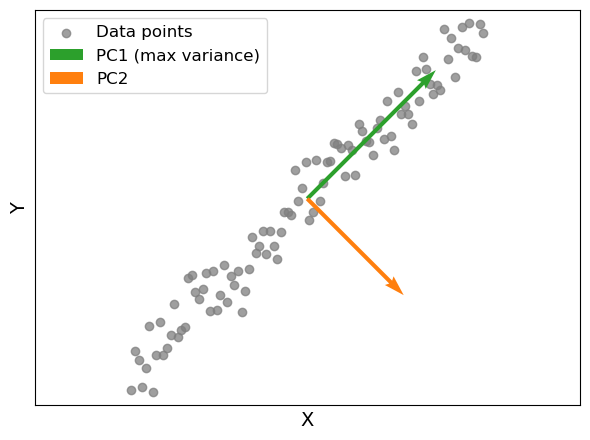

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# generate data roughly along y = 2*x
np.random.seed(123)
x = np.linspace(0, 10, 100)
y = 2 * x + np.random.normal(0, 1, size=x.shape)
X = np.vstack((x, y)).T

# standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Principal component directions (vectors)
pc_vectors = pca.components_

# plot original data with PC1 and PC2 vectors
plt.figure(figsize=(6, 4.5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], alpha=0.75, color="tab:gray", label='Data points')

# plot PC1 and PC2 vectors
origin = np.mean(X_scaled, axis=0)
plt.quiver(*origin, pc_vectors[0,0], pc_vectors[0,1], 
           color='tab:green', scale=3, label='PC1 (max variance)')
plt.quiver(*origin, pc_vectors[1,0], pc_vectors[1,1], 
           color='tab:orange', scale=4, label='PC2')

plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)
# plt.title("PCA on y = 2*x data")
plt.axis('equal')
plt.xticks([])
plt.yticks([])
plt.legend(fontsize=12)
plt.tight_layout()
# plt.show()
plt.savefig("./5-pca-data-representation.png")

# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)